# 4 · Priors, likelihoods and distances

Three of the four pluggable axes. A **prior** says what parameter values are allowed; a
**likelihood** says how well a prediction matches the data; a **distance** is the likelihood-free
alternative that ABC uses.

**Needs:** the base install only.

In [1]:
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "tests" / "data").is_dir())
AT2017GFO = ROOT / "tests" / "data" / "at2017gfo.csv"

import warnings
warnings.filterwarnings("ignore")           # keep the tutorial output readable

import numpy as np
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__)

whisper_cbpf 0.2.0


## Priors

Five distributions, and a `Prior` that collects them. `Uniform` and `LogUniform` give a box.
`LogUniform` is the right choice for anything spanning decades — a mass, a timescale, an opacity —
because it is flat in the logarithm, and the GPU samplers sample it in log space. `Normal` and
`TruncatedNormal` carry a measurement you already have, a host redshift or an explosion epoch, and
`Fixed` holds a parameter at a value so that it is no longer fitted or counted.

In [2]:
u = wp.Uniform(0.0, 10.0, name="t0")
lg = wp.LogUniform(0.1, 100.0, name="tau")

print("Uniform    bounds", u.bounds, " log_prob(5.0) =", f"{u.log_prob(5.0):.4f}")
print("LogUniform bounds", lg.bounds, " log_prob(1.0) =", f"{lg.log_prob(1.0):.4f}")
print("outside the support ->", u.log_prob(11.0))

Uniform    bounds (0.0, 10.0)  log_prob(5.0) = -2.3026
LogUniform bounds (0.1, 100.0)  log_prob(1.0) = -1.9326
outside the support -> -inf


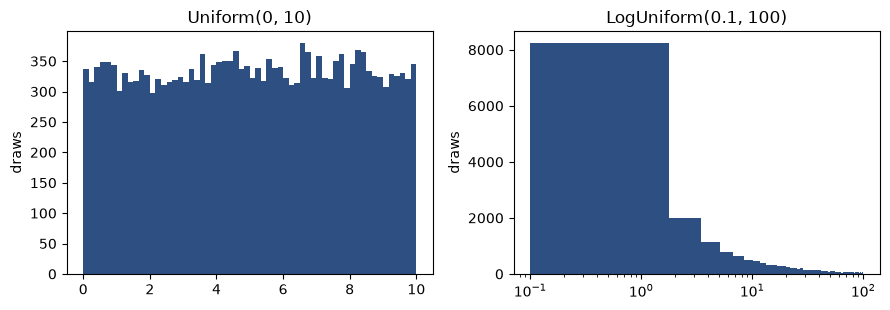

one draw from each: 0.5330508472860085 0.8272075645016405


In [3]:
rng = np.random.default_rng(0)

# `sample(rng)` draws one value; `rescale(u)` maps a uniform [0,1) draw through the inverse CDF,
# which is what the nested sampler uses and what vectorises.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, d, title in zip(axes, (u, lg), ("Uniform(0, 10)", "LogUniform(0.1, 100)")):
    draws = np.array([d.rescale(x) for x in rng.random(20000)])
    ax.hist(draws, bins=60, color="#08306b", alpha=0.85)
    ax.set_title(title); ax.set_ylabel("draws")
    if "Log" in title:
        ax.set_xscale("log")
plt.tight_layout(); plt.show()

print("one draw from each:", u.sample(rng), lg.sample(rng))

In [4]:
# A measured value with an error, with or without hard limits; and a value held fixed.
z_host = wp.TruncatedNormal(0.05, 0.01, 0.0, 1.0, name="redshift")
t_exp = wp.Normal(61000.0, 1.5, name="t_exp")
kappa = wp.Fixed(0.1, name="kappa")

for d in (z_host, t_exp, kappa):
    print(f"  {d!s:36s} bounds {d.bounds}")
print()
print("held fixed in a Prior:", wp.Prior({"t_exp": t_exp, "kappa": kappa}).fixed)

  TruncatedNormal(0.05, 0.01, 0.0, 1.0) bounds (0.0, 1.0)
  Normal(61000.0, 1.5)                 bounds (-inf, inf)
  Fixed(0.1)                           bounds (0.1, 0.1)

held fixed in a Prior: {'kappa': 0.1}


In [5]:
prior = wp.Prior({
    "amplitude": wp.Uniform(0.0, 5.0, name="amplitude"),
    "t0":        wp.Uniform(0.0, 20.0, name="t0"),
    "tau_rise":  wp.LogUniform(0.5, 20.0, name="tau_rise"),
    "tau_fall":  wp.LogUniform(1.0, 60.0, name="tau_fall"),
})
print(prior)
print()
draw = prior.sample(rng=rng)
print("one draw:", {k: round(float(v), 3) for k, v in draw.items()})
print("log_prob:", f"{prior.log_prob(draw):.4f}")

Prior({'amplitude': Uniform(0.0, 5.0), 't0': Uniform(0.0, 20.0), 'tau_rise': LogUniform(0.5, 20.0), 'tau_fall': LogUniform(1.0, 60.0)})

one draw: {'amplitude': 1.887, 't0': 1.076, 'tau_rise': 0.774, 'tau_fall': 14.092}
log_prob: -9.7101


## Likelihoods

Four of them, all registered by name. Which you want depends on what your data has.

| name | use it when |
|---|---|
| `gaussian` (`normal`) | plain errors, no outliers, no upper limits |
| `scatter` (`villar`) | there is extra unmodelled scatter — adds a fitted `sigma` |
| `upper_limits` (`ul`) | the light curve carries non-detections |
| `mixture` (`outlier`) | some points are simply wrong |

With upper limits in the light curve, `make_likelihood(lc)` picks `upper_limits` by itself, in
flux space, at the limits' significance (`lc.meta["upper_limit_sigma"]`, 5 for the survey
presets).

In [6]:
print(wp.list_likelihoods())
print()
# The names above are aliases onto four classes.
for cls in (wp.GaussianLikelihood, wp.GaussianLikelihoodWithScatter,
            wp.GaussianLikelihoodWithUpperLimits, wp.MixtureGaussianLikelihood):
    print(f"  {cls.__name__:36s} {cls.__doc__.splitlines()[0]}")

['gaussian', 'gaussian_scatter', 'gaussian_upper_limits', 'mixture', 'mixture_gaussian', 'normal', 'outlier', 'scatter', 'ul', 'upper_limits', 'villar']

  GaussianLikelihood                   Independent-Gaussian likelihood in flux or magnitude space.
  GaussianLikelihoodWithScatter        Gaussian likelihood with a FREE additional scatter term added in quadrature (Villar+2017).
  GaussianLikelihoodWithUpperLimits    Gaussian for detections + a censoring (CDF) term for upper limits — **flux space only**.
  MixtureGaussianLikelihood            Outlier-robust two-component Gaussian mixture (inlier ``sigma`` + wide ``sigma*scale``).


In [7]:
lc = wp.load_lightcurve(AT2017GFO, redshift=0.0098)
lc = lc.select_bands(["g"]).set_explosion_date(57982.529).select_time_window(0.0, 10.0)
if "upper_limit" in lc.colnames:
    lc = lc.where(upper_limit=False)      # the plain Gaussian refuses censored rows, by design

model = wp.get_model("bazin")
params = {"amplitude": 1.2e-4, "t0": 1.0, "tau_rise": 1.0, "tau_fall": 5.0}
flux = model.predict(params, np.asarray(lc["time"]), np.asarray(lc["band"]))

for kind in ["gaussian", "scatter", "mixture"]:
    lik = wp.make_likelihood(lc, kind=kind, space="magnitude")
    # `scatter` takes the extra white-noise term as an argument; it is a fitted parameter.
    value = lik.log_likelihood(flux, 0.1) if kind == "scatter" else lik.log_likelihood(flux)
    print(f"  {kind:9s} {type(lik).__name__:36s} logL = {value:11.3f}   {lik.summary()}")

# `upper_limits` is flux-space only. This light curve has no censored rows, so only its
# detection term contributes.
print()
try:
    ul = wp.make_likelihood(lc, kind="upper_limits", space="flux")
    print("  upper_limits  logL =", ul.log_likelihood(flux))
except Exception as exc:
    print("  upper_limits ->", f"{type(exc).__name__}: {str(exc)[:120]}")

  gaussian  GaussianLikelihood                   logL =  -35678.305   {'likelihood': 'gaussian', 'space': 'magnitude', 'n_data': 53}
  scatter   GaussianLikelihoodWithScatter        logL =   -2869.481   {'likelihood': 'gaussian_scatter', 'space': 'magnitude', 'n_data': 53, 'scatter_param': 'sigma'}
  mixture   MixtureGaussianLikelihood            logL =    -500.155   {'likelihood': 'mixture_gaussian', 'space': 'magnitude', 'n_data': 53, 'alpha': 0.9}

  upper_limits  logL = -94773.66820939533


### Registering your own likelihood

Subclass `GaussianLikelihood` and register it. The registry is the same shape as the model and
sampler ones.

In [8]:
from whisper_cbpf.likelihood import GaussianLikelihood


class HuberLikelihood(GaussianLikelihood):
    """Gaussian core, linear tails past `delta` sigma -- less sensitive to a few bad points.

    The base class has already put the observations in `self.y`, their errors in `self.sigma`, and
    resolved the comparison space; `model_in_space` converts a model flux into that same space.
    """

    delta = 3.0

    def log_likelihood(self, model_flux):
        r = np.abs((self.y - self.model_in_space(model_flux)) / self.sigma)
        rho = np.where(r <= self.delta, 0.5 * r ** 2, self.delta * (r - 0.5 * self.delta))
        return float(-np.sum(rho) + self._log_norm)


wp.register_likelihood("huber", HuberLikelihood, overwrite=True)
print("registered:", "huber" in wp.list_likelihoods())
print("logL:", wp.make_likelihood(lc, kind="huber", space="magnitude").log_likelihood(flux))

registered: True
logL: -3499.5195748995407


## Distances

ABC never evaluates a likelihood — it simulates and measures how far the simulation is from the
data. Seven distances ship, each with a `_jax` twin for the GPU samplers (`chi_square` is another
name for `chi2`). `max_abs_z` is the worst single point in sigma, so a threshold on it reads "every
point within k sigma".

In [9]:
for name in wp.list_distances():
    print("  ", name)

   chi2
   chi2_jax
   chi_square
   chi_square_jax
   mae
   mae_jax
   max_abs_z
   max_abs_z_jax
   mse
   mse_jax
   rmse
   rmse_jax
   wmae
   wmae_jax
   wmse
   wmse_jax


In [10]:
obs = np.array([1.0, 2.0, 3.0, 4.0])
err = np.array([0.1, 0.1, 0.2, 0.2])
sim = np.array([1.05, 1.95, 3.2, 3.7])
bands_ = np.array(["g", "g", "r", "r"])

for name in ["chi2", "mse", "rmse", "mae", "wmse", "wmae", "max_abs_z"]:
    fn = wp.get_distance(name)
    print(f"  {name:10s} {fn(obs, err, sim, bands_):.5f}")

# chi2_distance is also importable directly; it is the default every ABC sampler uses.
print()
print("wp.chi2_distance is the default:", wp.chi2_distance(obs, err, sim, bands_))

  chi2       3.75000
  mse        0.03375
  rmse       0.18371
  mae        0.15000
  wmse       0.93750
  wmae       0.87500
  max_abs_z  1.50000

wp.chi2_distance is the default: 3.75


In [11]:
def median_abs_z(obs_flux, obs_flux_err, sim_flux, bands):
    """Typical disagreement, in sigma: the median point rather than the worst."""
    return float(np.median(np.abs((obs_flux - sim_flux) / obs_flux_err)))


wp.register_distance("median_abs_z", median_abs_z, overwrite=True)
print("median_abs_z ->", wp.get_distance("median_abs_z")(obs, err, sim, bands_))

median_abs_z -> 0.7500000000000007


## Where next

* [05 · CPU samplers](05_cpu_samplers.ipynb) — put the prior, likelihood and distance to work.
* [08 · Metrics and model comparison](08_metrics_and_comparison.ipynb) — the likelihood decides
  what WAIC means.